# Практические занятия Листок 2. Комплексные числа. Геометрия комплексных чисел


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cmath
import math
from scipy.special import gamma as gamma_func
from sympy import *
import sympy as sp
import mpmath as mp
mp.mp.dps = 15
init_printing()

plt.rcParams['figure.figsize'] = (8, 8)

### **2.1** Представьте в алгебраической, тригонометрической и показательных формах комплексные выражения.

In [70]:
def print_forms(name, z):
    r = abs(z); phi = cmath.phase(z)
    print(f"{name}:")
    print(f"  Алгебраическая:     {z.real:.6f} + ({z.imag:.6f})i")
    print(f"  Тригонометрическая: {r:.6f}·(cos({phi:.6f}) + i·sin({phi:.6f}))")
    print(f"  Показательная:      {r:.6f}·e^({phi:.6f}i)")
    print()

z_a = (5+1j)*(7-6j)/(3+1j)
print_forms("2.1 a)", z_a)

z_b = (1+1j)**5/(1-1j)**3
print_forms("2.1 b)", z_b)

z_c = (-1+1j*np.sqrt(3))**15/(1-1j)**20 + (-1-1j*np.sqrt(3))**15/(1+1j)**20
z_c = complex(round(z_c.real), round(z_c.imag))
print_forms("2.1 c)", z_c)

2.1 a):
  Алгебраическая:     10.000000 + (-11.000000)i
  Тригонометрическая: 14.866069·(cos(-0.832981) + i·sin(-0.832981))
  Показательная:      14.866069·e^(-0.832981i)

2.1 b):
  Алгебраическая:     2.000000 + (-0.000000)i
  Тригонометрическая: 2.000000·(cos(-0.000000) + i·sin(-0.000000))
  Показательная:      2.000000·e^(-0.000000i)

2.1 c):
  Алгебраическая:     -64.000000 + (0.000000)i
  Тригонометрическая: 64.000000·(cos(3.141593) + i·sin(3.141593))
  Показательная:      64.000000·e^(3.141593i)



### **2.2** Решить $z^8 = 1+i$ и изобразить на комплексной плоскости.

Корни z^8 = 1+i:
  z_0 = +1.039245 +0.102357i
  z_1 = +0.662480 +0.807235i
  z_2 = -0.102357 +1.039245i
  z_3 = -0.807235 +0.662480i
  z_4 = -1.039245 -0.102357i
  z_5 = -0.662480 -0.807235i
  z_6 = +0.102357 -1.039245i
  z_7 = +0.807235 -0.662480i


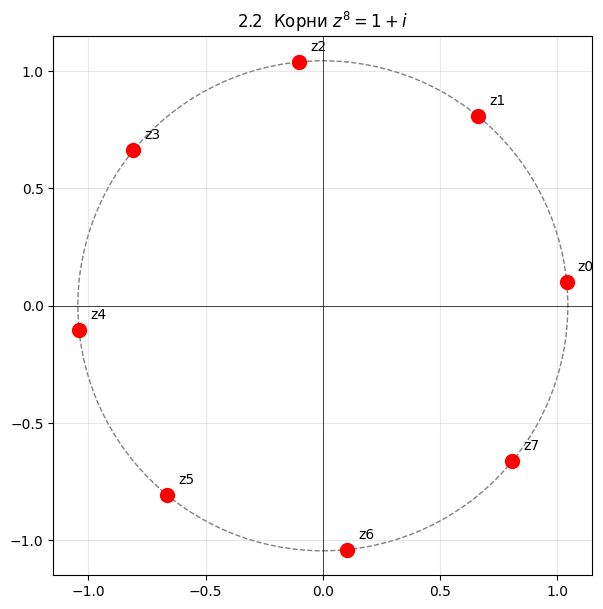

In [71]:
w = 1 + 1j
r = abs(w)**(1/8)
phi = cmath.phase(w)
roots = [r*cmath.exp(1j*(phi + 2*cmath.pi*k)/8) for k in range(8)]

print("Корни z^8 = 1+i:")
for k, z in enumerate(roots):
    print(f"  z_{k} = {z.real:+.6f} {z.imag:+.6f}i")

fig, ax = plt.subplots(figsize=(7,7))
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.add_patch(plt.Circle((0,0), r, fill=False, color='gray', ls='--'))
for k, z in enumerate(roots):
    ax.plot(z.real, z.imag, 'ro', ms=10)
    ax.annotate(f"z{k}", (z.real, z.imag), xytext=(8,8), textcoords="offset points")
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title("2.2  Корни $z^8 = 1+i$")
plt.show()

### **2.3** Вычислите (над полем $C$) и изобразите на комплексной плоскости.

2.3 a) ^8√1:
  z_0 = +1.000000 +0.000000i
  z_1 = +0.707107 +0.707107i
  z_2 = +0.000000 +1.000000i
  z_3 = -0.707107 +0.707107i
  z_4 = -1.000000 +0.000000i
  z_5 = -0.707107 -0.707107i
  z_6 = -0.000000 -1.000000i
  z_7 = +0.707107 -0.707107i

2.3 b):
  z_0 = +1.500000 +0.866025i
  z_1 = -0.866025 +1.500000i
  z_2 = -1.500000 -0.866025i
  z_3 = +0.866025 -1.500000i

2.3 c) подкоренное выражение = +9.000000 -8.000000i
2.3 c):
  z_0 = +2.225163 -0.549759i
  z_1 = -0.636476 +2.201928i
  z_2 = -1.588687 -1.652168i

2.3 d):
  z_0 = +1.035305 -0.090577i
  z_1 = +0.851311 +0.596095i
  z_2 = +0.268980 +1.003847i
  z_3 = -0.439210 +0.941889i
  z_4 = -0.941889 +0.439210i
  z_5 = -1.003847 -0.268980i
  z_6 = -0.596095 -0.851311i
  z_7 = +0.090577 -1.035305i
  z_8 = +0.734867 -0.734867i



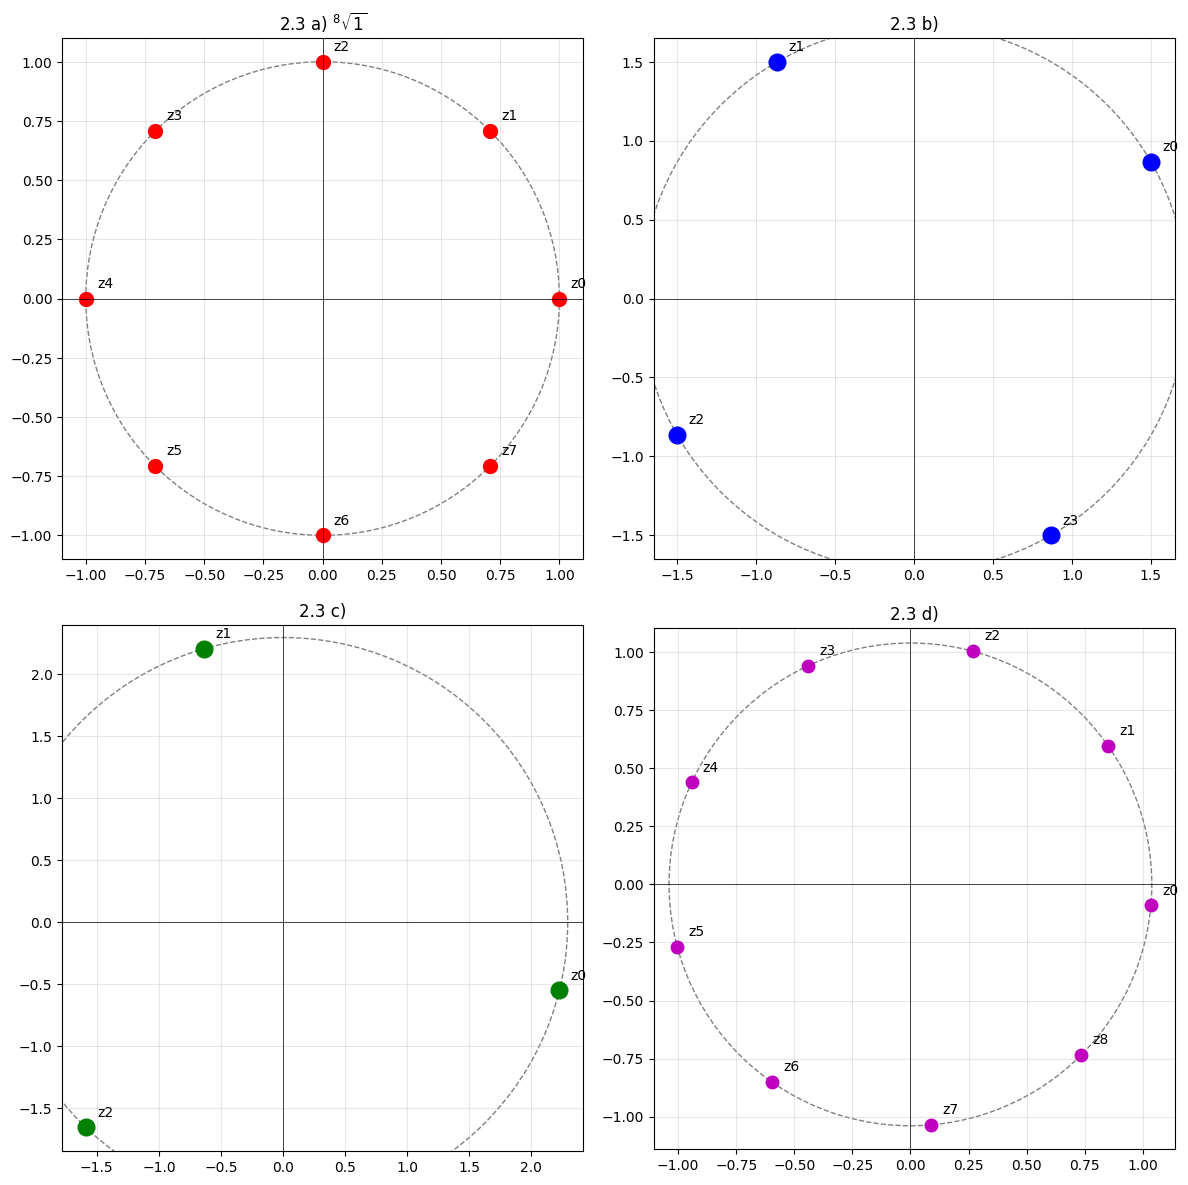

In [72]:
def nth_roots(w, n, name):
    r = abs(w)**(1/n); phi = cmath.phase(w)
    roots = [r*cmath.exp(1j*(phi + 2*cmath.pi*k)/n) for k in range(n)]
    print(f"{name}:")
    for k, z in enumerate(roots):
        print(f"  z_{k} = {z.real:+.6f} {z.imag:+.6f}i")
    print()
    return roots

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# a) степень 8
roots_a = nth_roots(1+0j, 8, "2.3 a) ^8√1")
ax = axes[0, 0]
for k, z in enumerate(roots_a):
    ax.plot(z.real, z.imag, 'ro', ms=10)
    ax.annotate(f"z{k}", (z.real, z.imag), xytext=(8, 8), textcoords="offset points")
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='gray', ls='--'))
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title(r"2.3 a) $^8\sqrt{1}$")     # <-- исправлено

# b)
w_b = -18/(1 + 1j*np.sqrt(3))
roots_b = nth_roots(w_b, 4, "2.3 b)")
ax = axes[0, 1]
for k, z in enumerate(roots_b):
    ax.plot(z.real, z.imag, 'bo', ms=12)
    ax.annotate(f"z{k}", (z.real, z.imag), xytext=(8, 8), textcoords="offset points")
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
r_b = abs(w_b)**0.25
ax.add_patch(plt.Circle((0, 0), r_b, fill=False, color='gray', ls='--'))
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.set_title("2.3 b)")

# c)
inner_c = (1-5j)/(1+1j) - 5*(1+2j)/(2-1j) + 11
print(f"2.3 c) подкоренное выражение = {inner_c.real:+.6f} {inner_c.imag:+.6f}i")
roots_c = nth_roots(inner_c, 3, "2.3 c)")
ax = axes[1, 0]
for k, z in enumerate(roots_c):
    ax.plot(z.real, z.imag, 'go', ms=12)
    ax.annotate(f"z{k}", (z.real, z.imag), xytext=(8, 8), textcoords="offset points")
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
r_c = abs(inner_c)**(1/3)
ax.add_patch(plt.Circle((0, 0), r_c, fill=False, color='gray', ls='--'))
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.set_title("2.3 c)")

# d) степень 9
roots_d = nth_roots(1-1j, 9, "2.3 d)")
ax = axes[1, 1]
for k, z in enumerate(roots_d):
    ax.plot(z.real, z.imag, 'mo', ms=9)
    ax.annotate(f"z{k}", (z.real, z.imag), xytext=(8, 8), textcoords="offset points")
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
r_d = abs(1-1j)**(1/9)
ax.add_patch(plt.Circle((0, 0), r_d, fill=False, color='gray', ls='--'))
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.set_title("2.3 d)")

plt.tight_layout(); plt.show()

### **2.4** Изобразите на комплексной плоскости множество точек, удовлетворяющих условию a); b); c); d); e); f).

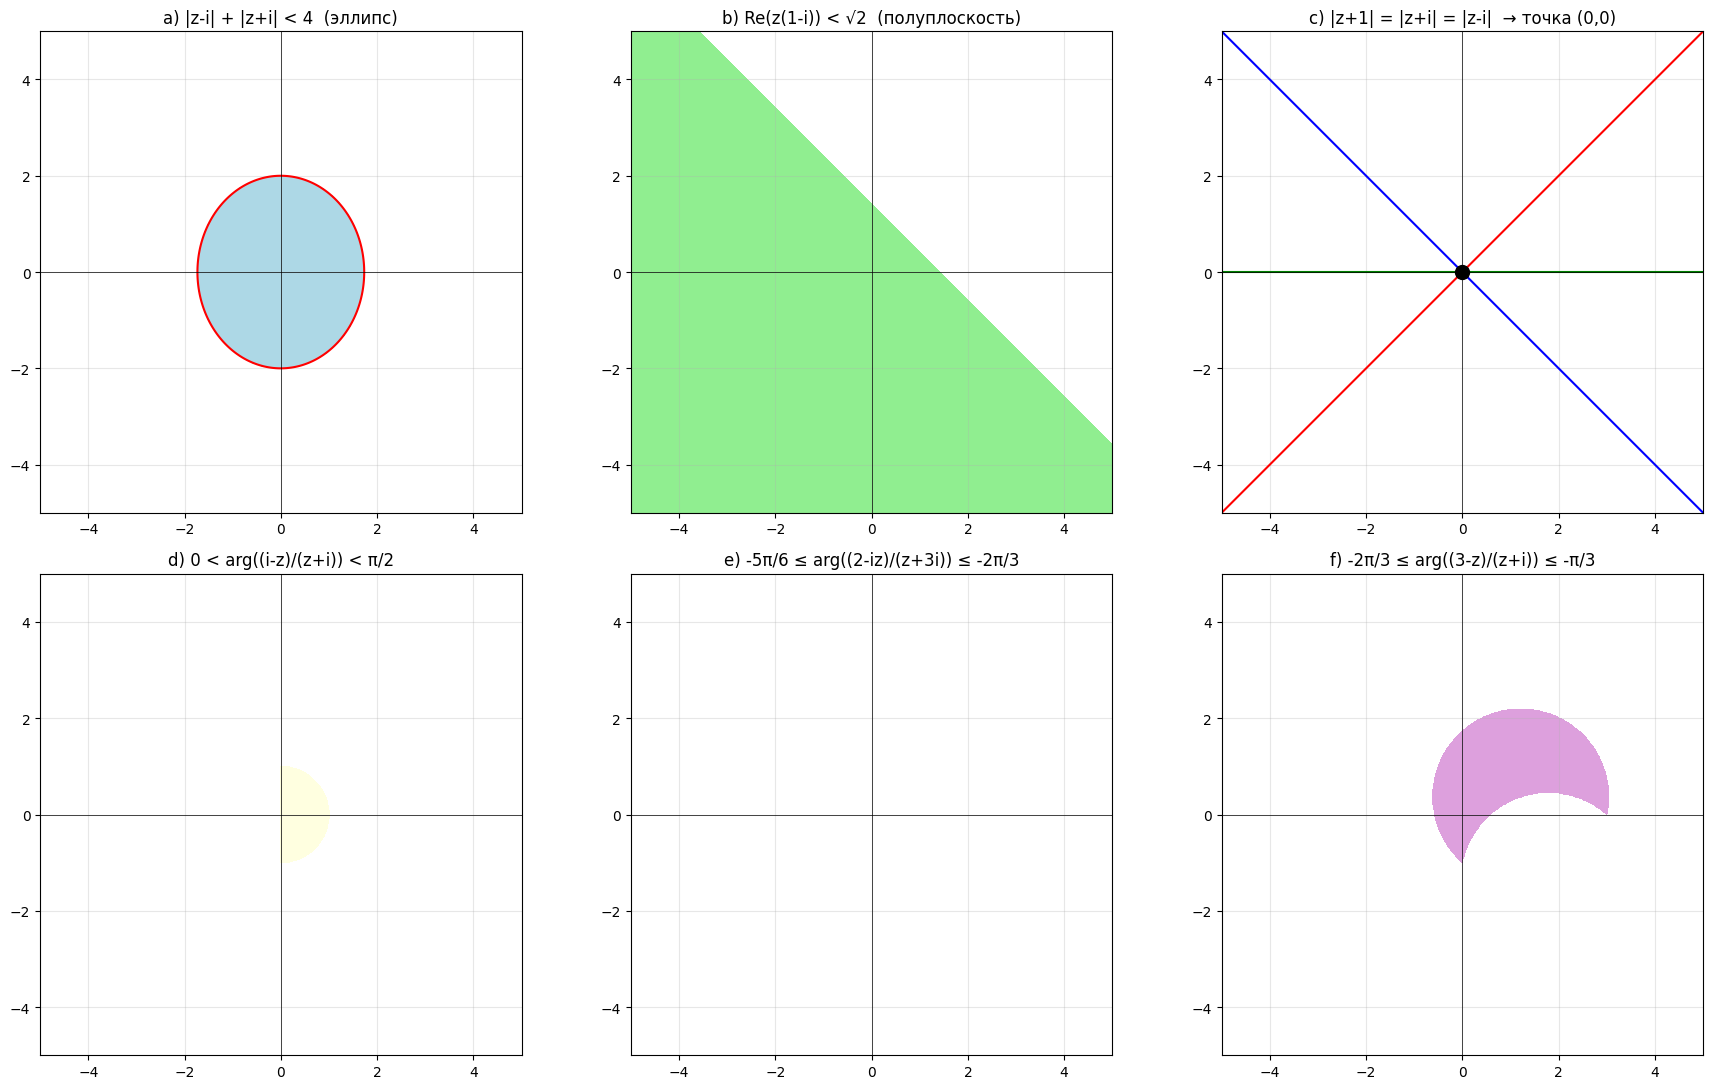

In [73]:
x = np.linspace(-5, 5, 800)
y = np.linspace(-5, 5, 800)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

def finish_complex_plot(ax, title):
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

cond_a = np.abs(Z - 1j) + np.abs(Z + 1j) < 4
ax = axes[0, 0]
ax.contourf(X, Y, cond_a, levels=[0.5, 1], colors=['lightblue'])
ax.contour(X, Y, np.abs(Z - 1j) + np.abs(Z + 1j), levels=[4], colors='red')
finish_complex_plot(ax, "a) |z-i| + |z+i| < 4  (эллипс)")

cond_b = np.real(Z*(1-1j)) < np.sqrt(2)
ax = axes[0, 1]
ax.contourf(X, Y, cond_b, levels=[0.5, 1], colors=['lightgreen'])
finish_complex_plot(ax, "b) Re(z(1-i)) < √2  (полуплоскость)")

ax = axes[0, 2]
d1 = np.abs(Z + 1) - np.abs(Z + 1j)
d2 = np.abs(Z + 1j) - np.abs(Z - 1j)
d3 = np.abs(Z + 1) - np.abs(Z - 1j)
ax.contour(X, Y, d1, levels=[0], colors='red')
ax.contour(X, Y, d2, levels=[0], colors='green')
ax.contour(X, Y, d3, levels=[0], colors='blue')
ax.plot(0, 0, 'ko', ms=10)
finish_complex_plot(ax, "c) |z+1| = |z+i| = |z-i|  → точка (0,0)")

ratio_d = (1j - Z) / (Z + 1j)
arg_d = np.angle(ratio_d)
cond_d = (arg_d > 0) & (arg_d < np.pi/2)
ax = axes[1, 0]
ax.contourf(X, Y, cond_d, levels=[0.5, 1], colors=['lightyellow'])
finish_complex_plot(ax, "d) 0 < arg((i-z)/(z+i)) < π/2")

ratio_e = (2 - 1j*Z) / (Z + 3j)
arg_e = np.angle(ratio_e)
arg_e_min, arg_e_max = -2*np.pi/3, -5*np.pi/6
cond_e = (arg_e >= arg_e_min) & (arg_e <= arg_e_max)
ax = axes[1, 1]
ax.contourf(X, Y, cond_e, levels=[0.5, 1], colors=['lightsalmon'])
finish_complex_plot(ax, "e) -5π/6 ≤ arg((2-iz)/(z+3i)) ≤ -2π/3")

ratio_f = (3 - Z) / (Z + 1j)
arg_f = np.angle(ratio_f)
cond_f = (arg_f >= -2*np.pi/3) & (arg_f <= -np.pi/3)
ax = axes[1, 2]
ax.contourf(X, Y, cond_f, levels=[0.5, 1], colors=['plum'])
finish_complex_plot(ax, "f) -2π/3 ≤ arg((3-z)/(z+i)) ≤ -π/3")

plt.tight_layout(); plt.show()

### **2.5** Покажите, что уравнение уравнение окружности $A|z|^2 + not(B)z + Bnot(z) + C = 0$ является уравнением окружности, а также найдите центр этой окружности и её радиус.


In [74]:
# Пусть B = u + iv. Тогда not(B) z + B z̄ = 2 Re(not(B) z).
# В координатах (x, y): A(x²+y²) + 2(ux − vy) + C = 0
# Дополняем до квадрата:
#   (x + u/A)² + (y − v/A)² = (u² + v² − AC)/A²
# Центр: z₀ = −B/A  (в комплексной записи)
# Радиус: R = √(|B|² − AC)/A
#
# Проверка численно:
A_num, B_num, C_num = 2.0, 3+4j, 1.0
u, v = B_num.real, B_num.imag
z0 = -B_num / A_num
R = np.sqrt(abs(B_num)**2 - A_num*C_num) / A_num
print(f"Центр: z_0 = {z0.real:.6f} + {z0.imag:.6f}i")
print(f"Радиус: R = {R:.6f}")
print(f"(A={A_num}, B={B_num}, C={C_num}, AC={A_num*C_num} < |B|²={abs(B_num)**2})")

Центр: z_0 = -1.500000 + -2.000000i
Радиус: R = 2.397916
(A=2.0, B=(3+4j), C=1.0, AC=2.0 < |B|²=25.0)


### **2.6** Корни многочлена 11-й степени.

In [75]:
coeffs = [1, 1, 0, 1, -2, 0, -1, 1, 0, 2, 2, 2]
roots = np.roots(coeffs)

print("Все 11 корней:")
for k, z in enumerate(roots):
    print(f"  z_{k+1} = {z.real:+.6f} {z.imag:+.6f}i")

sum_moduli = np.sum(np.abs(roots))
print(f"\n1) Сумма модулей |z₁|+...+|z₁₁| = {sum_moduli:.6f}")

max_real = np.max(roots.real)
print(f"2) Максимальная действительная часть: {max_real:.6f}")

poly = np.poly1d(coeffs)
print(f"\nПроверка p(z_1) = {poly(roots[0]):.2e}")

Все 11 корней:
  z_1 = -1.776769 +0.000000i
  z_2 = +1.080602 +0.323893i
  z_3 = +1.080602 -0.323893i
  z_4 = +0.477755 +0.901075i
  z_5 = +0.477755 -0.901075i
  z_6 = -0.012500 +1.182699i
  z_7 = -0.012500 -1.182699i
  z_8 = -0.450037 +0.803923i
  z_9 = -0.450037 -0.803923i
  z_10 = -0.707434 +0.464375i
  z_11 = -0.707434 -0.464375i

1) Сумма модулей |z₁|+...+|z₁₁| = 11.973384
2) Максимальная действительная часть: 1.080602

Проверка p(z_1) = 1.65e-12+0.00e+00j


### **2.7** Обобщение биномиальных коэффициентов.

In [76]:
z_val = 1 + 1j
w_val = 1 - 1j

C_val = mp.gamma(z_val + 1) / (
    mp.gamma(w_val + 1) * mp.gamma(z_val - w_val + 1)
)
C_val = complex(C_val)

print(f"2.7 a) C_{{1+i}}^{{1-i}} = {C_val.real:.5f} {C_val.imag:+.5f}i")

arg_val = cmath.phase(C_val)
print(f"2.7 b) Arg = {arg_val:.6f} рад = {np.degrees(arg_val):.4f}°")

2.7 a) C_{1+i}^{1-i} = 4.36745 +4.85163i
2.7 b) Arg = 0.837869 рад = 48.0064°


In [77]:
x = np.linspace(-2, 2, 700)
y = np.linspace(-2, 2, 700)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
    W = 1 / Z
    log_coefficient = (
        loggamma(Z + 1)
        - loggamma(W + 1)
        - loggamma(Z - W + 1)
    )
    phase = np.angle(np.exp(1j * log_coefficient.imag))

invalid = ~np.isfinite(log_coefficient) | (np.abs(Z) < 1e-12)
phase_image = np.ma.array(phase, mask=invalid)

# Не проводим ложные линии уровня через скачок Arg от pi к -pi
jump = np.zeros(Z.shape, dtype=bool)
jump_x = np.abs(np.diff(phase, axis=1)) > np.pi
jump_y = np.abs(np.diff(phase, axis=0)) > np.pi
jump[:, 1:] |= jump_x
jump[:, :-1] |= jump_x
jump[1:, :] |= jump_y
jump[:-1, :] |= jump_y

phase_contours = np.ma.array(phase, mask=invalid | jump)

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(
    phase_image,
    extent=(-2, 2, -2, 2),
    origin="lower",
    cmap="twilight",
    vmin=-np.pi,
    vmax=np.pi,
    interpolation="nearest",
)

levels = np.linspace(-np.pi, np.pi, 13)[1:-1]
ax.contour(
    X, Y, phase_contours,
    levels=levels,
    colors="black",
    linewidths=0.45,
    alpha=0.65,
)

ax.scatter([0], [0], s=12, facecolors="white", edgecolors="black")
ax.set(
    title=r"Линии уровня $\mathrm{Arg}(C_z^{1/z})$",
    xlabel="Re z",
    ylabel="Im z",
    aspect="equal",
)

bar = fig.colorbar(
    image,
    ax=ax,
    ticks=[-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
)
bar.ax.set_yticklabels(
    [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"]
)
bar.set_label("Аргумент, рад")

plt.tight_layout()
plt.show()

TypeError: bad operand type for abs(): 'ImmutableDenseNDimArray'

### **2.8** Даны матрицы: I, A. Найдите определитель матрицы A + λI и укажите в ответе: 1) действительную часть этого определителя; 2) его мнимуючасть.


In [ ]:
k = 1
lam = cmath.exp(1j * 2 * cmath.pi * k / 14)
print(f"λ = {lam.real:.6f} + {lam.imag:.6f}i")

A_mat = np.array([[7, 5], [6, 2]], dtype=complex)
M = A_mat + lam * np.eye(2)
det_M = np.linalg.det(M)

print(f"\ndet(A + λI) = {det_M.real:.6f} + {det_M.imag:.6f}i")
print(f"1) Действительная часть: {det_M.real:.6f}")
print(f"2) Мнимая часть:          {det_M.imag:.6f}")

det_analytical = lam**2 + 9*lam - 16
print(f"\nАналитически: {det_analytical.real:.6f} + {det_analytical.imag:.6f}i")

λ = 0.900969 + 0.433884i

det(A + λI) = -7.267790 + 4.686785i
1) Действительная часть: -7.267790
2) Мнимая часть:          4.686785

Аналитически: -7.267790 + 4.686785i


### **2.9** Множества Жюлиа

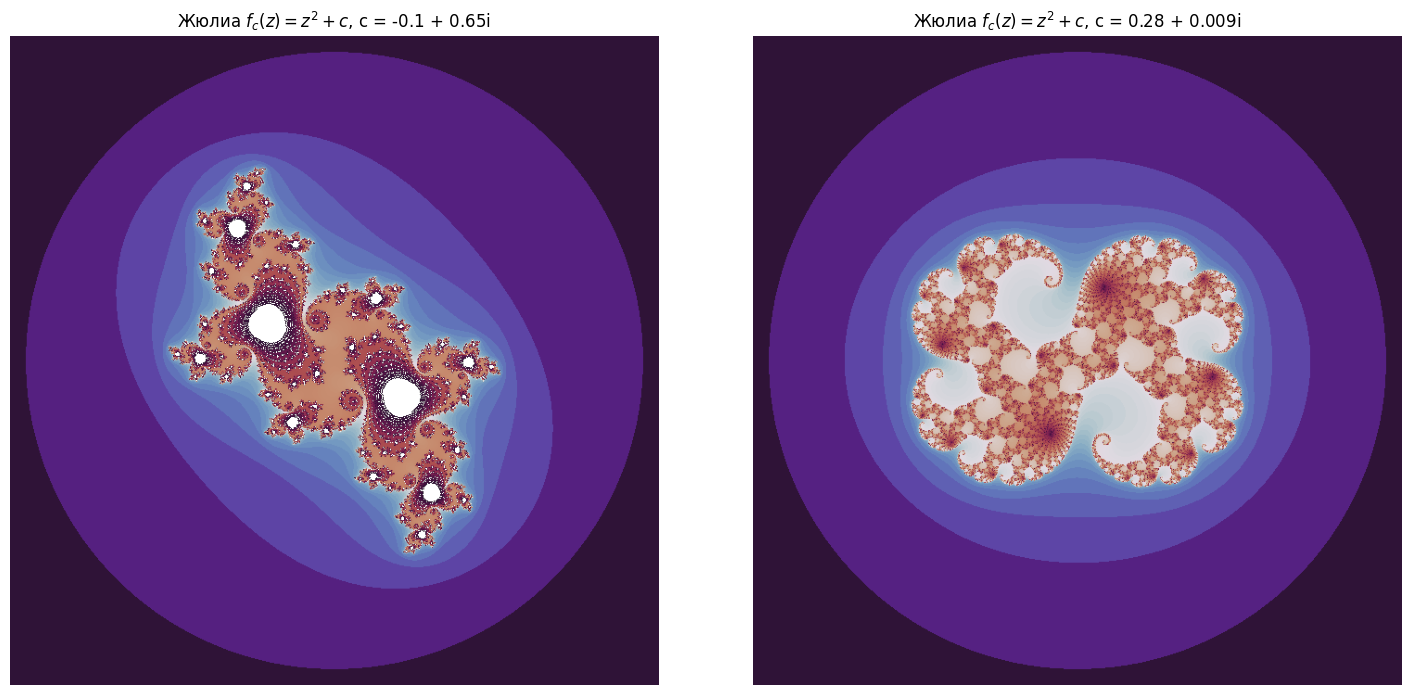

In [ ]:
def quadratic_julia(c, size=700, max_iterations=700, limit=2.1):
    axis = np.linspace(-limit, limit, size)
    Z = axis[None, :] + 1j * axis[:, None]

    active = np.abs(Z) <= 2
    counts = np.full(Z.shape, max_iterations, dtype=int)
    counts[~active] = 0

    for iteration in range(1, max_iterations + 1):
        Z[active] = Z[active] ** 2 + c
        escaped = active & (np.abs(Z) > 2)
        counts[escaped] = iteration
        active[escaped] = False
        if not active.any():
            break

    return counts, active


fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, c, name in zip(
    axes,
    [-0.1 + 0.65j, 0.28 + 0.009j],
    ["c = -0.1 + 0.65i", "c = 0.28 + 0.009i"],
):
    counts, bounded = quadratic_julia(c)
    image = np.ma.array(np.log1p(counts), mask=bounded)

    ax.imshow(
        image.T,
        cmap="twilight_shifted",
        extent=[-2.1, 2.1, -2.1, 2.1],
        origin="lower",
    )
    ax.set_title(f"Жюлиа $f_c(z)=z^2+c$, {name}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Степень 5: глубина 8, построено 390625 прообразов.
Степень 2: глубина 19, построено 524288 прообразов.


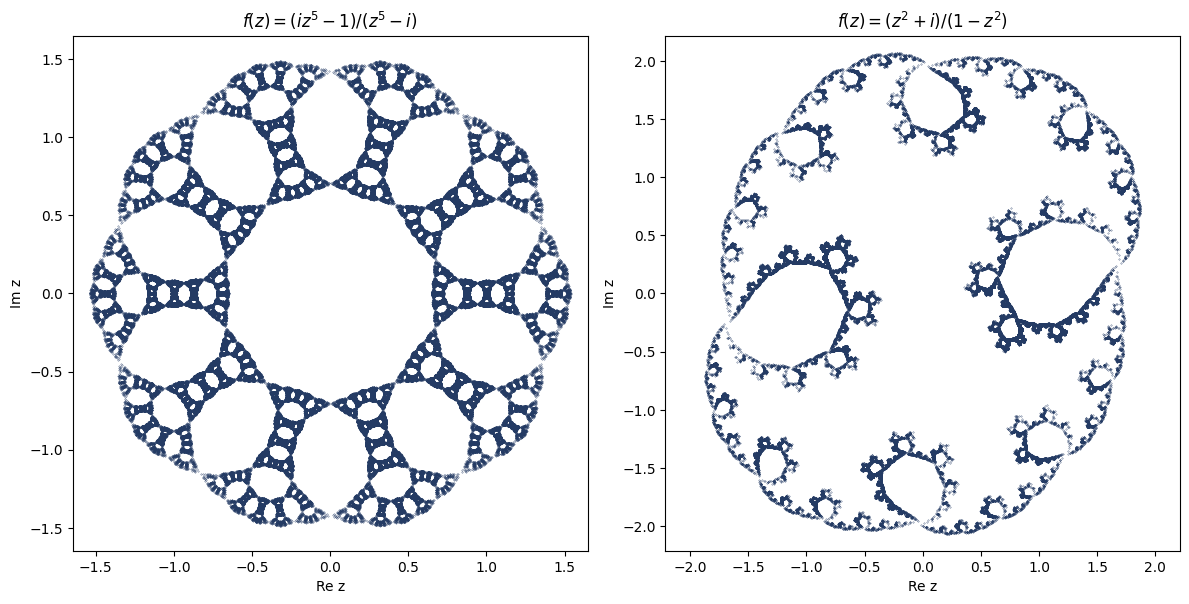

In [ ]:
# Рациональные отображения: метод обратных итераций
def rational_julia(numerator, denominator, degree, depth, inverse_power):
    variable = sp.symbols("z")

    fixed_points = np.array([
        complex(root)
        for root in sp.nroots(
            numerator - variable * denominator,
            maxsteps=200,
        )
    ])

    derivative = sp.lambdify(
        variable,
        sp.diff(numerator / denominator, variable),
        "numpy",
    )
    multipliers = np.abs(derivative(fixed_points))
    seed = fixed_points[np.argmax(multipliers)]

    points = np.array([seed], dtype=complex)
    branches = np.exp(2j * np.pi * np.arange(degree) / degree)

    for _ in range(depth):
        powers = inverse_power(points)
        principal = (
            np.abs(powers) ** (1 / degree)
            * np.exp(1j * np.angle(powers) / degree)
        )
        preimages = np.concatenate([principal * branch for branch in branches])
        points = preimages

    return points


z = sp.symbols("z")

rational_cases = [
    (
        sp.I * z ** 5 - 1,
        z ** 5 - sp.I,
        5,
        8,
        lambda w: (1j * w - 1) / (w - 1j),
        r"$f(z)=(iz^5-1)/(z^5-i)$",
    ),
    (
        z ** 2 + sp.I,
        1 - z ** 2,
        2,
        19,
        lambda w: (w - 1j) / (w + 1),
        r"$f(z)=(z^2+i)/(1-z^2)$",
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, (numerator, denominator, degree, depth, inverse_power, title) in zip(
    axes, rational_cases
):
    points = rational_julia(
        numerator, denominator, degree, depth, inverse_power
    )

    ax.scatter(
        points.real,
        points.imag,
        s=0.06,
        color="#243B64",
        rasterized=True,
    )

    limit = 1.07 * max(
        np.max(np.abs(points.real)),
        np.max(np.abs(points.imag)),
    )
    ax.set(
        title=title,
        xlabel="Re z",
        ylabel="Im z",
        aspect="equal",
        xlim=(-limit, limit),
        ylim=(-limit, limit),
    )

    print(
        f"Степень {degree}: глубина {depth}, "
        f"построено {len(points)} прообразов."
    )

plt.tight_layout()
plt.show()

### **2.10** Сфера Римана: a) прямая, b) окружность, c) парабола, d) гипербола и e) логарифмическая спираль, заданную уравнением $r = ae^{bϕ}$.

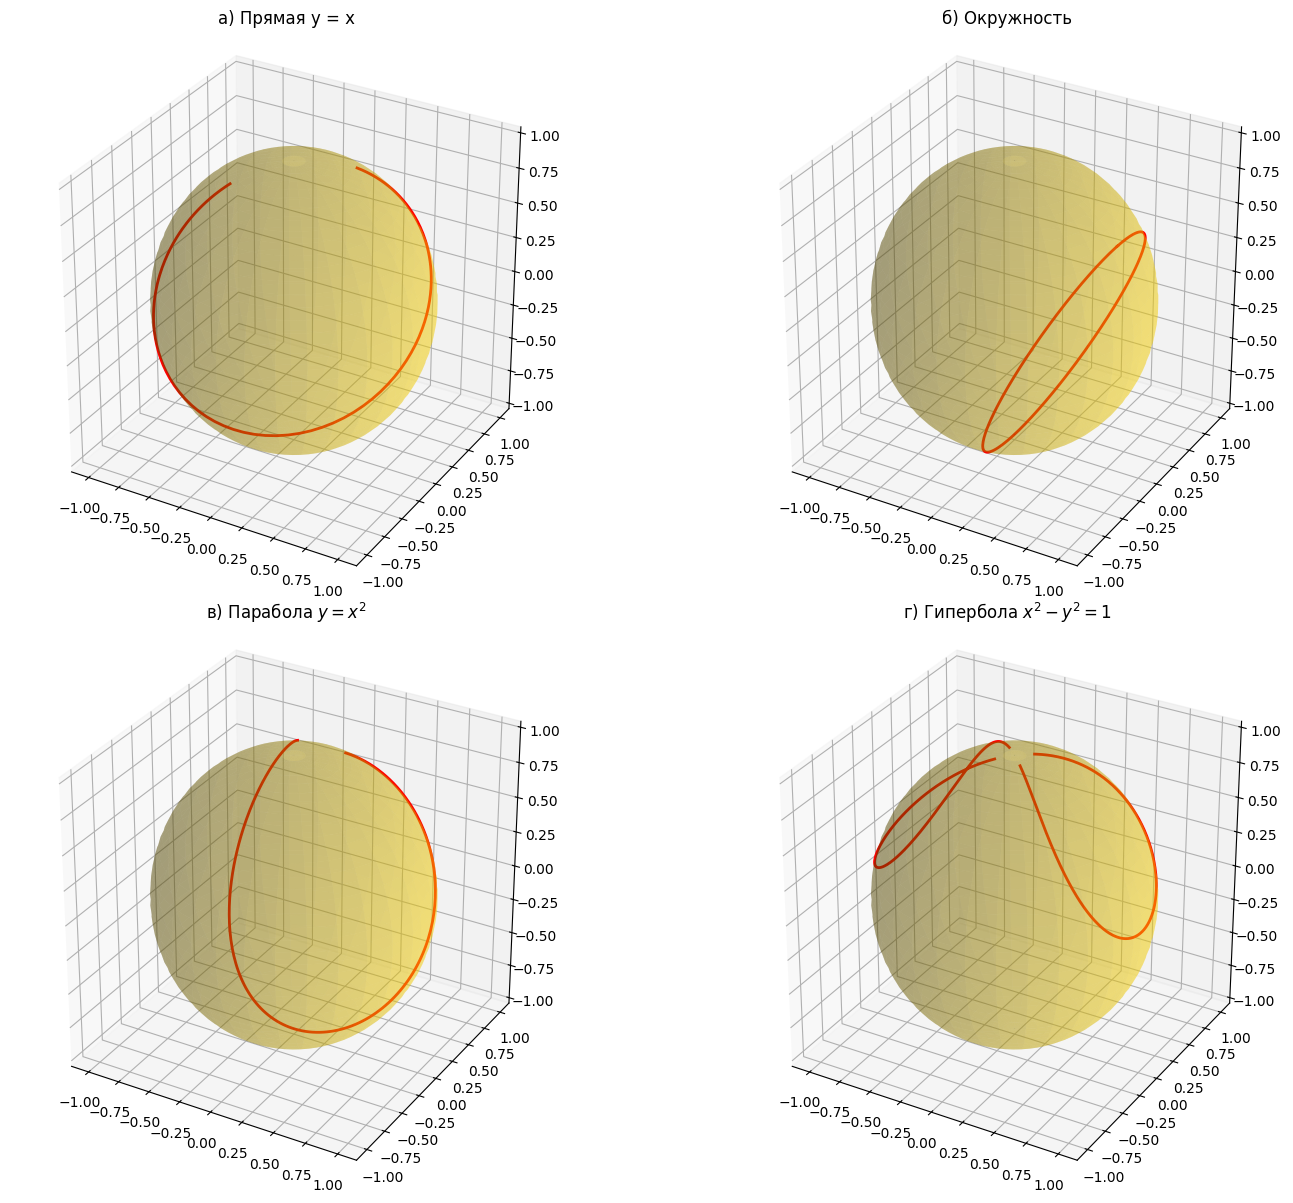

In [ ]:
# кривые
def project_to_sphere(x, y):
    r2 = x**2 + y**2
    denom = 1 + r2
    return 2*x/denom, 2*y/denom, (r2 - 1)/denom


u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 40)
U, V = np.meshgrid(u, v)
Xs = np.sin(V)*np.cos(U)
Ys = np.sin(V)*np.sin(U)
Zs = np.cos(V)

fig = plt.figure(figsize=(16, 12))

# а) Прямая
ax = fig.add_subplot(2, 2, 1, projection='3d')
ax.plot_surface(Xs, Ys, Zs, alpha=0.3, color='gold')
t = np.linspace(-3, 3, 200)
Xp, Yp, Zp = project_to_sphere(t, t)
ax.plot(Xp, Yp, Zp, 'r-', lw=2)
ax.set_title("а) Прямая y = x")
ax.set_box_aspect([1, 1, 1])

# б) Окружность
ax = fig.add_subplot(2, 2, 2, projection='3d')
ax.plot_surface(Xs, Ys, Zs, alpha=0.3, color='gold')
theta = np.linspace(0, 2*np.pi, 300)
Xp, Yp, Zp = project_to_sphere(1 + np.cos(theta), np.sin(theta))
ax.plot(Xp, Yp, Zp, 'r-', lw=2)
ax.set_title("б) Окружность")
ax.set_box_aspect([1, 1, 1])

# в) Парабола
ax = fig.add_subplot(2, 2, 3, projection='3d')
ax.plot_surface(Xs, Ys, Zs, alpha=0.3, color='gold')
t = np.linspace(-2, 2, 300)
Xp, Yp, Zp = project_to_sphere(t, t**2)
ax.plot(Xp, Yp, Zp, 'r-', lw=2)
ax.set_title("в) Парабола $y = x^2$")
ax.set_box_aspect([1, 1, 1])

# г) Гипербола (обе ветви)
ax = fig.add_subplot(2, 2, 4, projection='3d')
ax.plot_surface(Xs, Ys, Zs, alpha=0.3, color='gold')
t = np.linspace(-3, 3, 400)
Xp, Yp, Zp = project_to_sphere(np.cosh(t), np.sinh(t))
ax.plot(Xp, Yp, Zp, 'r-', lw=2)
Xp, Yp, Zp = project_to_sphere(-np.cosh(t), np.sinh(t))
ax.plot(Xp, Yp, Zp, 'r-', lw=2)
ax.set_title("г) Гипербола $x^2 - y^2 = 1$")
ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

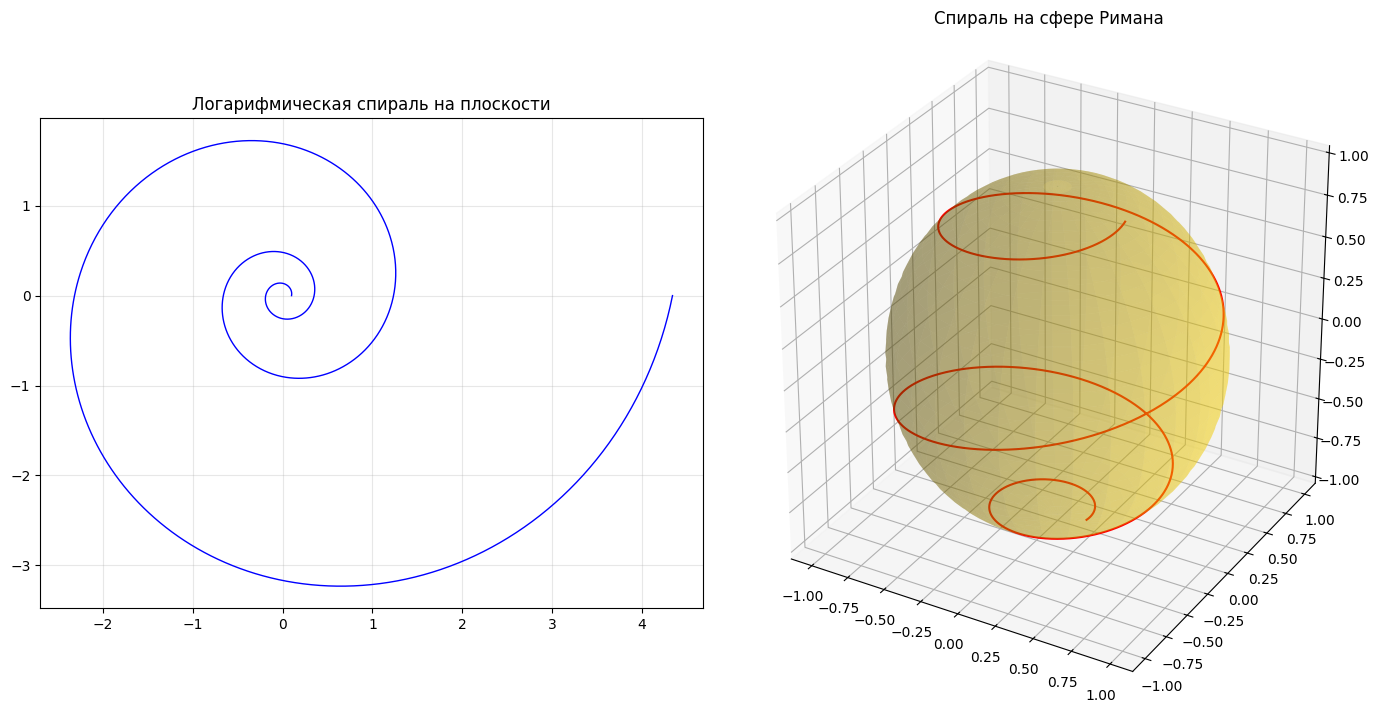

In [ ]:
a, b = 0.1, 0.2
phi = np.linspace(0, 6*np.pi, 2000)
r = a * np.exp(b*phi)
x_sp = r * np.cos(phi)
y_sp = r * np.sin(phi)

fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x_sp, y_sp, 'b-', lw=1)
ax1.set_aspect('equal'); ax1.grid(alpha=0.3)
ax1.set_title("Логарифмическая спираль на плоскости")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(Xs, Ys, Zs, alpha=0.3, color='gold')
Xp, Yp, Zp = project_to_sphere(x_sp, y_sp)
ax2.plot(Xp, Yp, Zp, 'r-', lw=1.5)
ax2.set_title("Спираль на сфере Римана")
ax2.set_box_aspect([1,1,1])
plt.tight_layout(); plt.show()